In [33]:
from pathlib import Path
from astropy import units as un
import numpy as np

from edges.cal import sparams as sp
from edges import io
from edges import data as datatools
from edges import alanmode

import matplotlib.pyplot as plt

In [73]:
#original_cal = alanmode.read_s11_csv("/data5/edges/data/S11_antenna/low_band/S11_blade_low_band_2015_342_03_14.txt")
s11freq, s11real, s11imag = np.genfromtxt(
   "/data5/edges/data/S11_antenna/low_band/S11_blade_low_band_2015_342_03_14.txt",
).T
mask = (s11freq >=50e6) & (s11freq<=100e6)
s11freq = s11freq[mask]/1e6
orig_s11 = s11real[mask] + 1j*s11imag[mask]

In [3]:
datadir = Path("/data5/edges/data/S11_antenna/low_band/20151207/s11/")

In [87]:
alls11 = sorted(datadir.glob("run*.s1p"))

In [88]:
alls11

[PosixPath('/data5/edges/data/S11_antenna/low_band/20151207/s11/run_0002_input1_20151208_031435.s1p'),
 PosixPath('/data5/edges/data/S11_antenna/low_band/20151207/s11/run_0002_input2_20151208_031443.s1p'),
 PosixPath('/data5/edges/data/S11_antenna/low_band/20151207/s11/run_0002_input3_20151208_031451.s1p'),
 PosixPath('/data5/edges/data/S11_antenna/low_band/20151207/s11/run_0002_input4_20151208_031459.s1p')]

In [89]:
ck = sp.CalkitReadings.from_filespec(
    io.CalkitFileSpec(
        open=alls11[0],
        short=alls11[1],
        match=alls11[2]
    )
)

ants11 = sp.ReflectionCoefficient.from_s1p(alls11[3])

In [90]:
def get_switch_state_filespec(d: Path):
    return io.InternalSwitch(
        internal = io.CalkitFileSpec(
            open = d / 'open.S1P',
            short = d/ 'short.S1P',
            match = d/ 'load.S1P',
        ),
        external = io.CalkitFileSpec(
            open = d / 'open_input.S1P',
            short = d/ 'short_input.S1P',
            match = d/ 'load_input.S1P',
        ),
    )

In [126]:
CALKITKW = {"match": {"offset_delay": 30*un.picosecond}}

In [120]:
s11root = datatools.fetch_b18cal_s11s()
internal_switch_paths = sorted((s11root / "InternalSwitch").glob("*degC"))
internal_switch_filespecs = [get_switch_state_filespec(d) for d in internal_switch_paths]

In [127]:
internal_switch = sp.get_internal_switch_from_caldef(internal_switch_filespecs, calkit_overrides=CALKITKW, measured_temperature=27.0*un.deg_C)

In [128]:
intsw_model_params = sp.internal_switch_model_params()

In [129]:
internal_switch_smooth = internal_switch.smoothed(params=intsw_model_params, freqs=ants11.freqs)

In [130]:
gamma_ant_cal = sp.calibrate_gamma_src(gamma_src=ants11, internal_osl=ck, internal_switch=internal_switch_smooth).select_frequencies(f_low=50*un.MHz, f_high=100*un.MHz)

Text(0, 0.5, 'Absolute Difference')

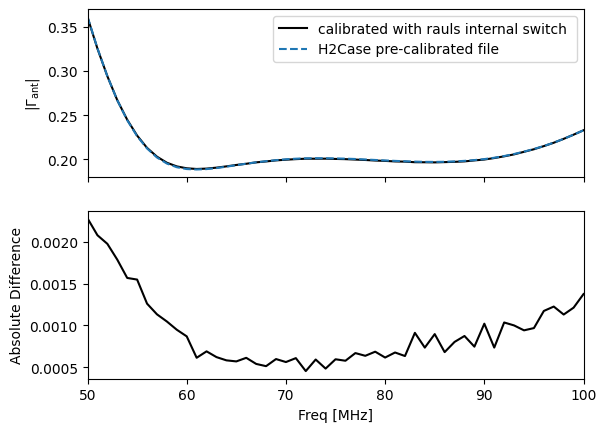

In [131]:
fig, ax = plt.subplots(2, 1, sharex=True)

plt.sca(ax[0])

plt.plot(gamma_ant_cal.freqs.to_value("MHz"), np.abs(gamma_ant_cal.reflection_coefficient), color='k', label='calibrated with rauls internal switch ')
plt.plot(s11freq, np.abs(orig_s11), color='C0', ls='--', label='H2Case pre-calibrated file')

plt.xlim(50,100)
#plt.ylim(0.15, 0.3)
plt.legend()
#plt.xlabel("Freq [MHz]")
plt.ylabel(r"$|\Gamma_{\rm ant}|$")


plt.sca(ax[1])

plt.plot(gamma_ant_cal.freqs.to_value("MHz"), np.abs(gamma_ant_cal.reflection_coefficient - orig_s11), color='k')

#plt.xlim(50,100)
plt
plt.xlabel("Freq [MHz]")
plt.ylabel(r"Absolute Difference")